In [1]:
# ===================================================================
# 셀 1: 기본 설정 및 데이터 로드
# ===================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import ast
import numpy as np
import os
from collections import Counter
from itertools import combinations
import networkx as nx

# 시각화를 위한 전역 설정
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 이미지 저장 디렉토리 생성
IMAGE_DIR = '../reports/images'
os.makedirs(IMAGE_DIR, exist_ok=True)

# 데이터 로드 및 기본 전처리
try:
    df = pd.read_csv('../data/processed_jobs.csv')
    df['tech_stack_list'] = df['tech_stack'].apply(ast.literal_eval)
    print("데이터 로드 및 전처리 완료.")
except FileNotFoundError:
    print("오류: '../data/processed_jobs.csv' 파일을 찾을 수 없습니다. 전처리 단계가 올바르게 완료되었는지 확인하세요.")

데이터 로드 및 전처리 완료.



--- 분석 1: 전체 기술 스택 수요 ---


C:\Users\parad\AppData\Local\Temp\ipykernel_44172\117184224.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=tech_counts.head(top_n).values,


그래프가 '../reports/images\1_top_15_tech_stack.png'에 저장되었습니다.


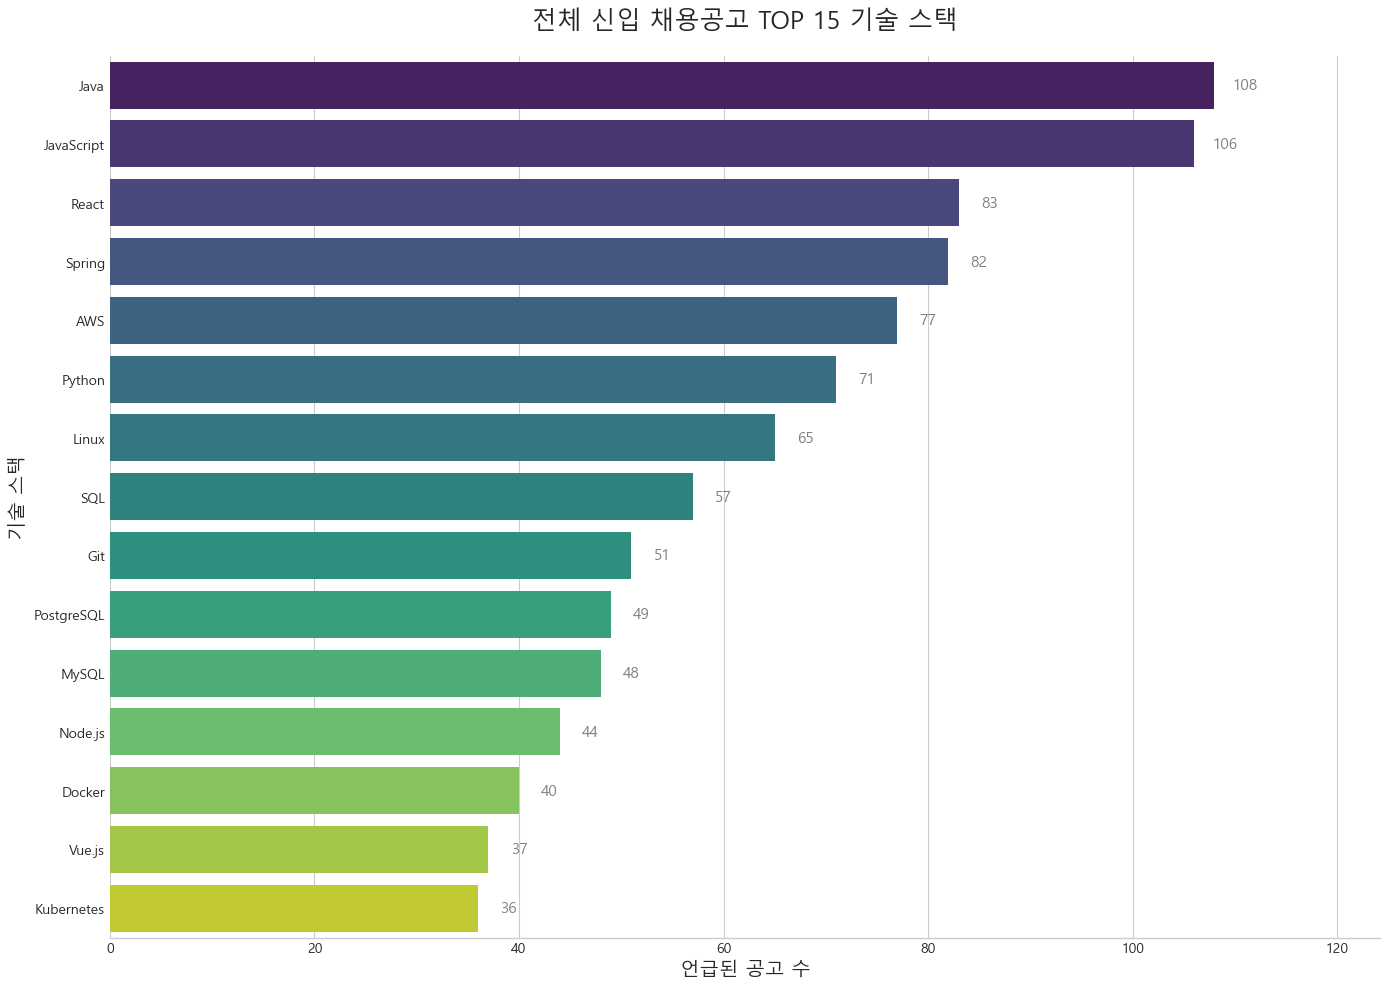

In [2]:
# ===================================================================
# 셀 2: 분석 1: 전체 기술 스택 수요 (Top 15)
# ===================================================================
print("\n--- 분석 1: 전체 기술 스택 수요 ---")
tech_counts = df['tech_stack_list'].explode().value_counts()

fig = plt.figure(figsize=(14, 10))
top_n = 15
palette = sns.color_palette("viridis", n_colors=top_n)
ax = sns.barplot(x=tech_counts.head(top_n).values,
                 y=tech_counts.head(top_n).index,
                 palette=palette,
                 orient='h')

for p in ax.patches:
    ax.text(
        p.get_width() + 3,
        p.get_y() + p.get_height() / 2.,
        f'{int(p.get_width())}',
        ha='center',
        va='center',
        fontsize=11,
        color='gray'
    )

ax.set_title('전체 신입 채용공고 TOP 15 기술 스택', fontsize=18, pad=20)
ax.set_xlabel('언급된 공고 수', fontsize=14)
ax.set_ylabel('기술 스택', fontsize=14)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', length=0)
plt.xlim(0, tech_counts.max() * 1.15)
plt.tight_layout()

# 이미지 파일로 저장
save_path = os.path.join(IMAGE_DIR, '1_top_15_tech_stack.png')
fig.savefig(save_path, bbox_inches='tight')
print(f"그래프가 '{save_path}'에 저장되었습니다.")

plt.show()


--- 분석 2: 직무별 기술 '채택률(%)' 비교 ---


C:\Users\parad\AppData\Local\Temp\ipykernel_44172\522147467.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(tick):.0f}%' for tick in ticks])


그래프가 '../reports/images\2_tech_rate_by_job.png'에 저장되었습니다.


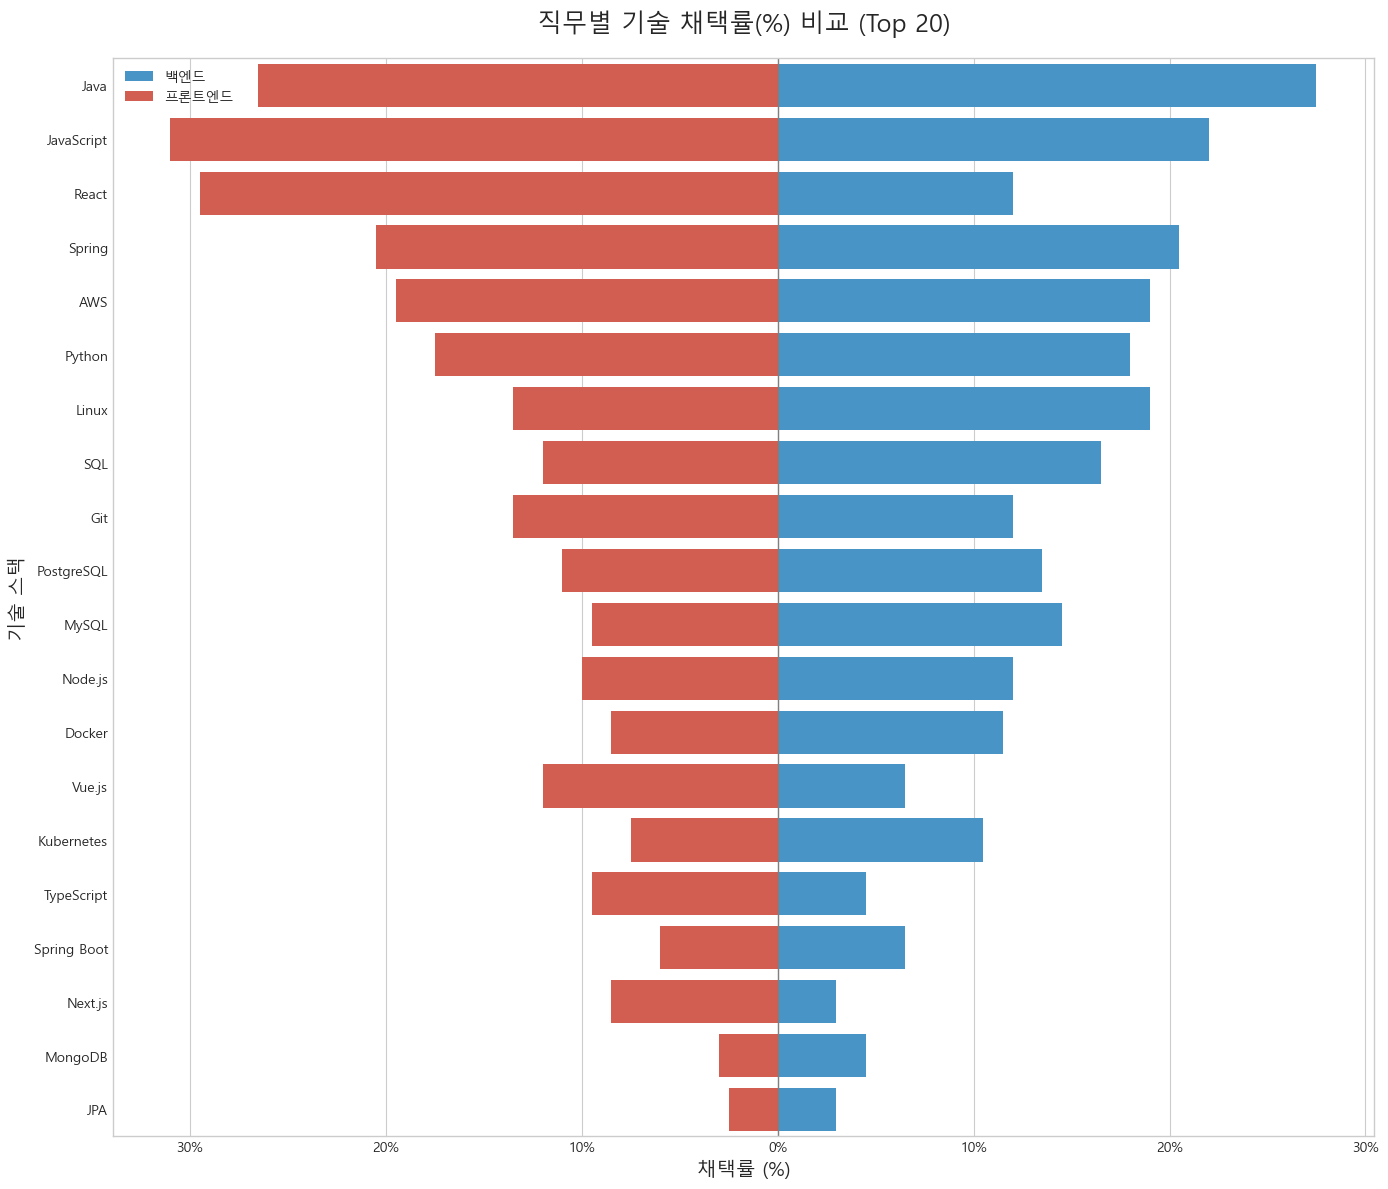

In [3]:
# ===================================================================
# 셀 3: 분석 2: 직무별 기술 '채택률(%)' 비교
# ===================================================================
print("\n--- 분석 2: 직무별 기술 '채택률(%)' 비교 ---")
total_backend_jobs = len(df[df['job_category'] == '백엔드'])
total_frontend_jobs = len(df[df['job_category'] == '프론트엔드'])

backend_counts = df[df['job_category'] == '백엔드']['tech_stack_list'].explode().value_counts()
frontend_counts = df[df['job_category'] == '프론트엔드']['tech_stack_list'].explode().value_counts()

backend_rate = (backend_counts / total_backend_jobs) * 100
frontend_rate = (frontend_counts / total_frontend_jobs) * 100

rate_df = pd.DataFrame({'백엔드(%)': backend_rate, '프론트엔드(%)': frontend_rate}).fillna(0)
rate_df['total'] = rate_df['백엔드(%)'] + rate_df['프론트엔드(%)']
rate_df = rate_df.sort_values('total', ascending=False).head(20)

rate_df['프론트엔드(%)'] = -rate_df['프론트엔드(%)']

fig, ax = plt.subplots(figsize=(14, 12))
sns.barplot(x='백엔드(%)', y=rate_df.index, data=rate_df,
            color='#3498db', label='백엔드', ax=ax)
sns.barplot(x='프론트엔드(%)', y=rate_df.index, data=rate_df,
            color='#e74c3c', label='프론트엔드', ax=ax)

ax.legend()
ax.set_title('직무별 기술 채택률(%) 비교 (Top 20)', fontsize=18, pad=20)
ax.set_xlabel('채택률 (%)', fontsize=14)
ax.set_ylabel('기술 스택', fontsize=14)
ax.axvline(0, color='grey', lw=1)

ticks = ax.get_xticks()
ax.set_xticklabels([f'{abs(tick):.0f}%' for tick in ticks])

plt.tight_layout()

# 이미지 파일로 저장
save_path = os.path.join(IMAGE_DIR, '2_tech_rate_by_job.png')
fig.savefig(save_path, bbox_inches='tight')
print(f"그래프가 '{save_path}'에 저장되었습니다.")

plt.show()


--- 분석 3: 주요 기술 조합 (Heatmap) ---


C:\Users\parad\AppData\Local\Temp\ipykernel_44172\2557044529.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  co_occurrence_df = pd.DataFrame(index=top_15_techs, columns=top_15_techs).fillna(0)


그래프가 '../reports/images\3_tech_combination_heatmap.png'에 저장되었습니다.


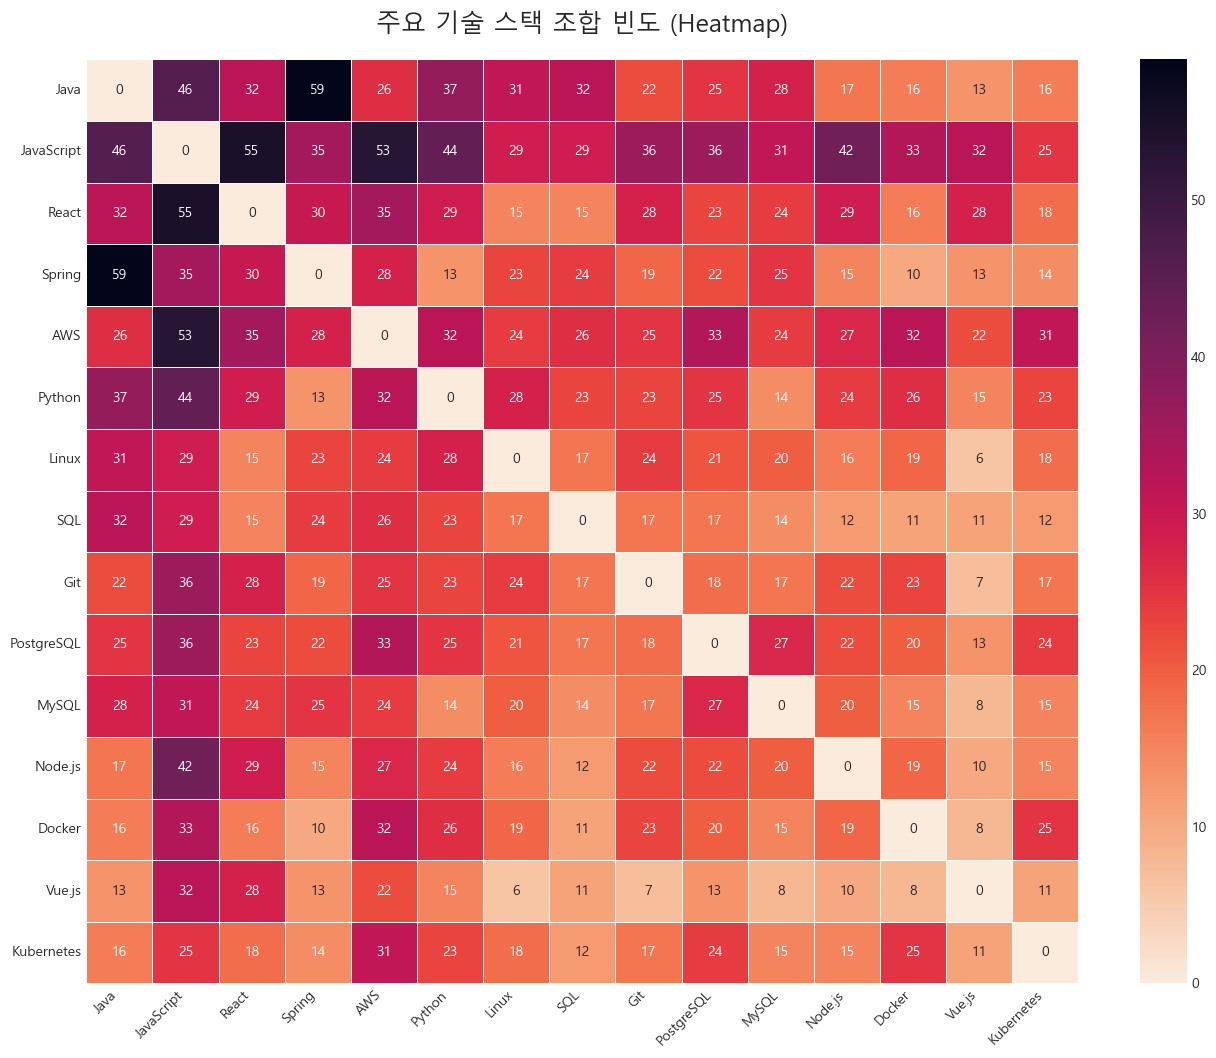

In [4]:
# ===================================================================
# 셀 4: 분석 3: 주요 기술 조합 (Heatmap)
# ===================================================================
print("\n--- 분석 3: 주요 기술 조합 (Heatmap) ---")
top_15_techs = tech_counts.head(15).index.tolist()
df['top_techs'] = df['tech_stack_list'].apply(
    lambda techs: [tech for tech in techs if tech in top_15_techs]
)

pairs = []
for techs in df['top_techs']:
    if len(techs) > 1:
        pairs.extend(list(combinations(sorted(techs), 2)))

pair_counts = Counter(pairs)

co_occurrence_df = pd.DataFrame(index=top_15_techs, columns=top_15_techs).fillna(0)

for pair, count in pair_counts.items():
    co_occurrence_df.loc[pair[0], pair[1]] = count
    co_occurrence_df.loc[pair[1], pair[0]] = count

fig = plt.figure(figsize=(16, 12))
sns.heatmap(co_occurrence_df, annot=True, fmt='.0f', cmap='rocket_r', linewidths=.5)
plt.title('주요 기술 스택 조합 빈도 (Heatmap)', fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# 이미지 파일로 저장
save_path = os.path.join(IMAGE_DIR, '3_tech_combination_heatmap.png')
fig.savefig(save_path, bbox_inches='tight')
print(f"그래프가 '{save_path}'에 저장되었습니다.")

plt.show()


--- 분석 4: 경력 요구사항별 기술 스택 비교 ---


C:\Users\parad\AppData\Local\Temp\ipykernel_44172\3254133301.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([int(abs(tick)) for tick in ticks])


그래프가 '../reports/images\4_tech_by_experience.png'에 저장되었습니다.


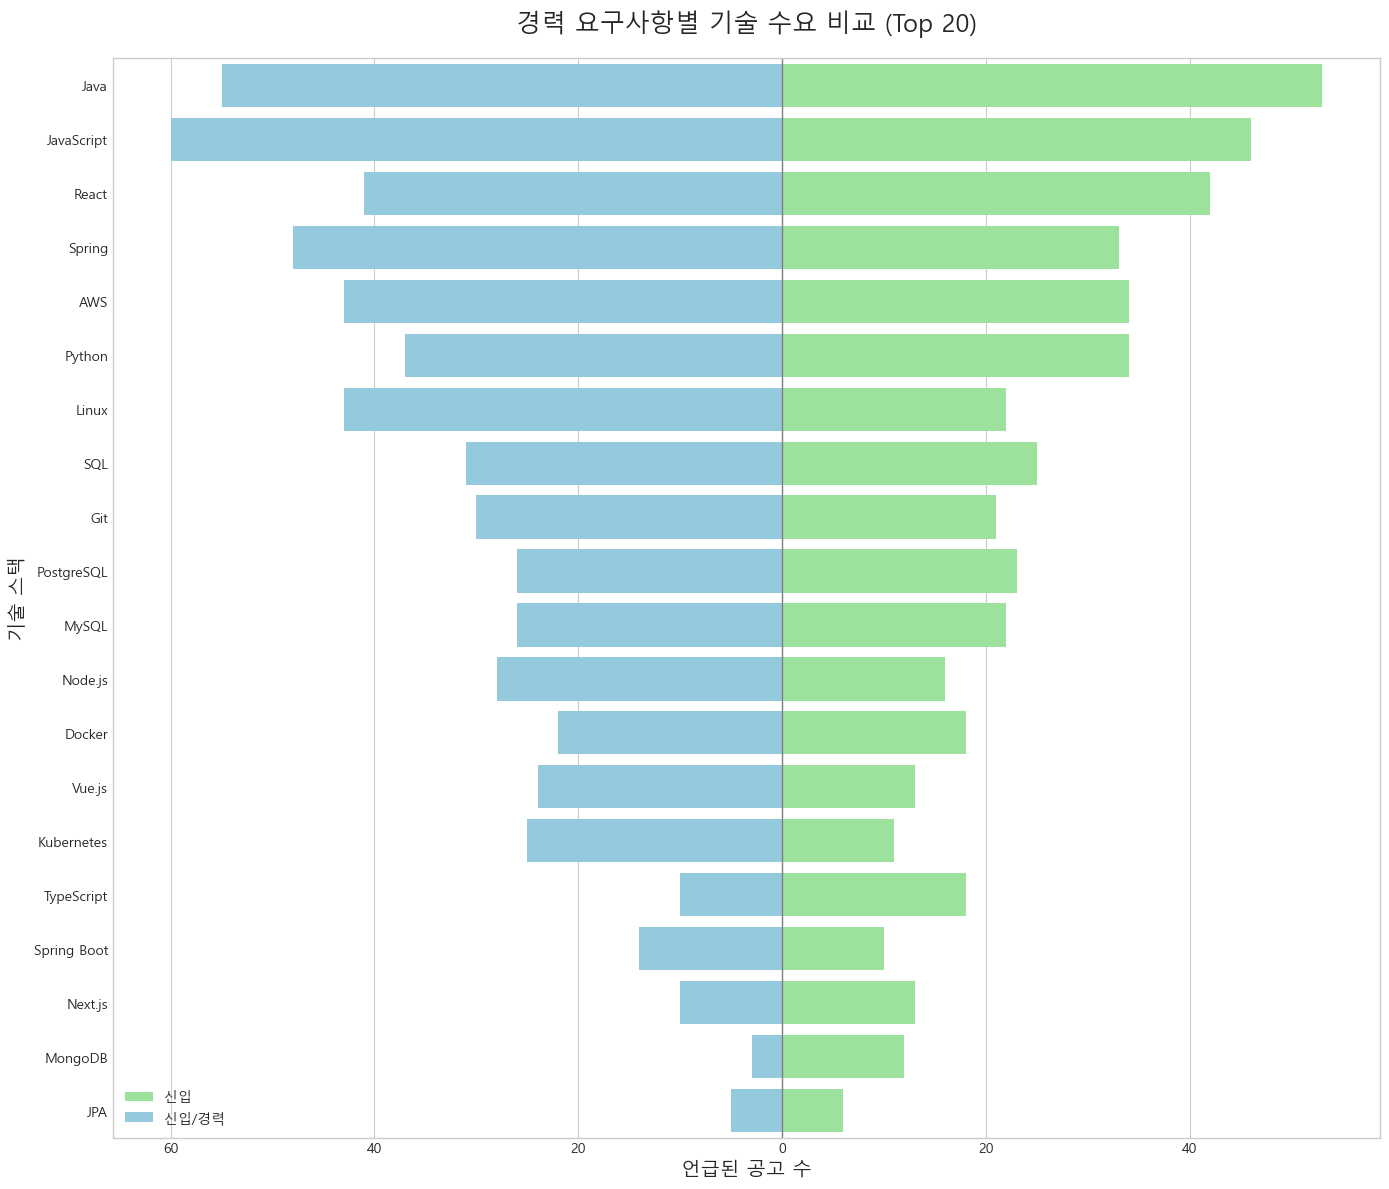

In [5]:
# ===================================================================
# 셀 5: 분석 4: 경력 요구사항별 기술 스택 비교
# ===================================================================
print("\n--- 분석 4: 경력 요구사항별 기술 스택 비교 ---")
newbie_df = df[df['experience'] == '신입']
newbie_plus_df = df[df['experience'] == '신입/경력']

newbie_counts = newbie_df['tech_stack_list'].explode().value_counts()
newbie_plus_counts = newbie_plus_df['tech_stack_list'].explode().value_counts()

exp_comp_df = pd.DataFrame({'신입': newbie_counts, '신입/경력': newbie_plus_counts}).fillna(0)
exp_comp_df['total'] = exp_comp_df['신입'] + exp_comp_df['신입/경력']
exp_comp_df = exp_comp_df.sort_values('total', ascending=False).head(20)

exp_comp_df['신입/경력'] = -exp_comp_df['신입/경력']

fig, ax = plt.subplots(figsize=(14, 12))
sns.barplot(x='신입', y=exp_comp_df.index, data=exp_comp_df,
            color='lightgreen', label='신입', ax=ax)
sns.barplot(x='신입/경력', y=exp_comp_df.index, data=exp_comp_df,
            color='skyblue', label='신입/경력', ax=ax)

ax.legend()
ax.set_title('경력 요구사항별 기술 수요 비교 (Top 20)', fontsize=18, pad=20)
ax.set_xlabel('언급된 공고 수', fontsize=14)
ax.set_ylabel('기술 스택', fontsize=14)
ax.axvline(0, color='grey', lw=1)

ticks = ax.get_xticks()
ax.set_xticklabels([int(abs(tick)) for tick in ticks])

plt.tight_layout()

# 이미지 파일로 저장
save_path = os.path.join(IMAGE_DIR, '4_tech_by_experience.png')
fig.savefig(save_path, bbox_inches='tight')
print(f"그래프가 '{save_path}'에 저장되었습니다.")

plt.show()


--- 분석 5: 주요 기술 스택별 연봉 분포 ---


C:\Users\parad\AppData\Local\Temp\ipykernel_44172\804314061.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='salary_numeric', y='tech_stack_list',
C:\Users\parad\AppData\Local\Temp\ipykernel_44172\804314061.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{tick/10000:.0f}만원' for tick in ticks])


그래프가 '../reports/images\5_salary_distribution_by_tech.png'에 저장되었습니다.


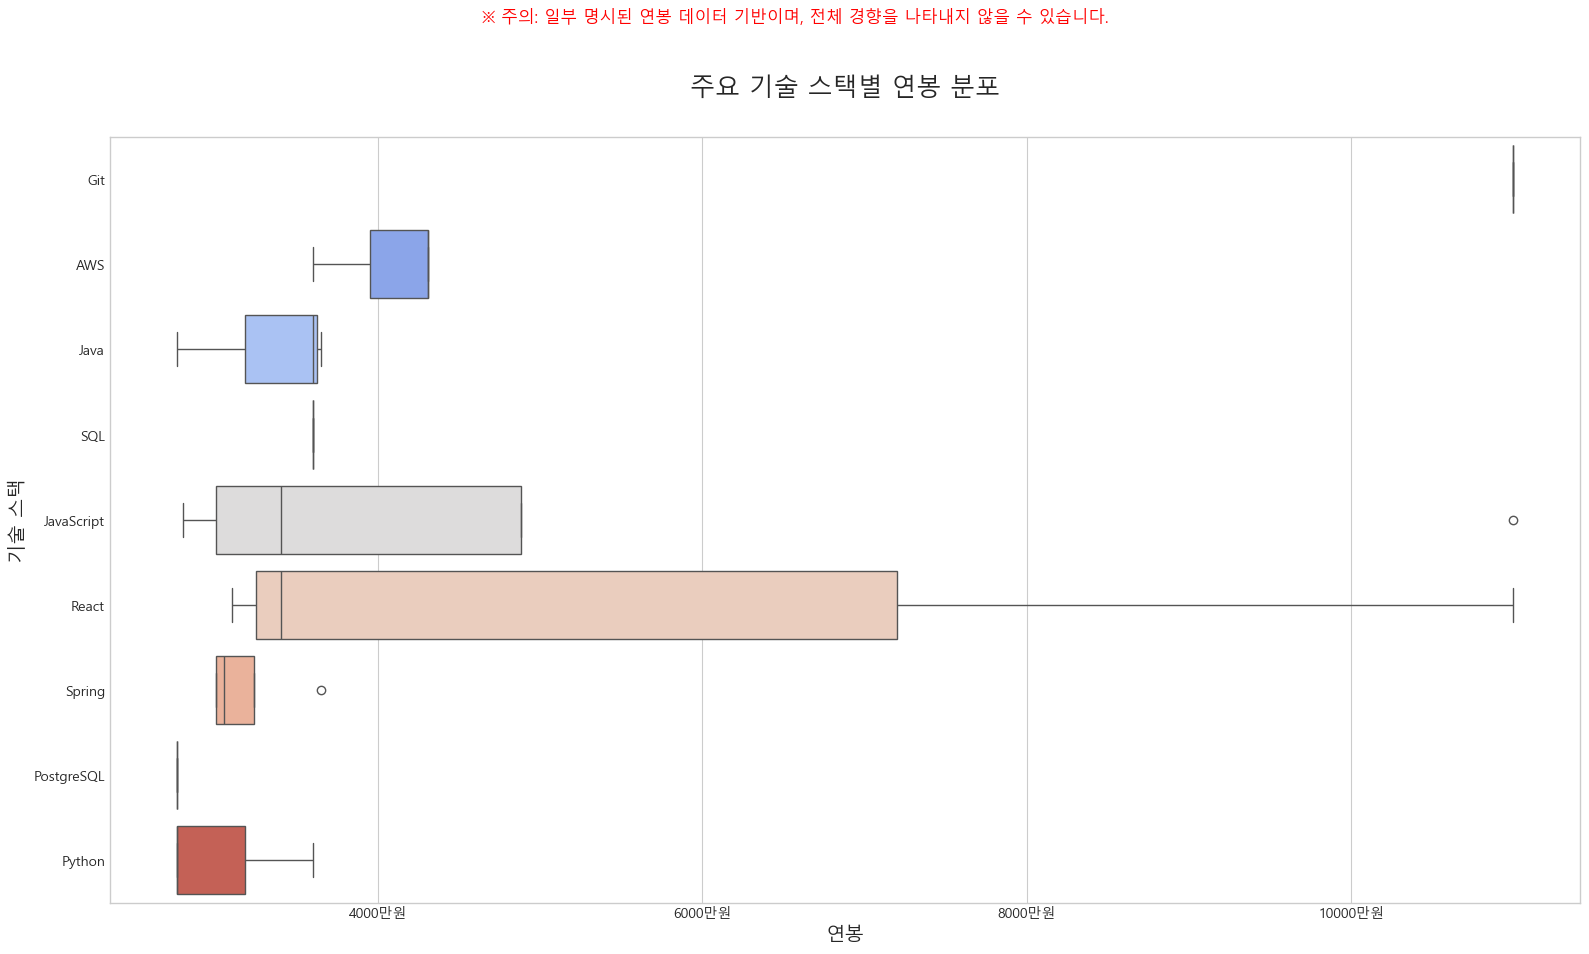

In [6]:
# ===================================================================
# 셀 6: 분석 5: 주요 기술 스택별 연봉 분포
# ===================================================================
print("\n--- 분석 5: 주요 기술 스택별 연봉 분포 ---")
salary_df = df[df['salary'] != '회사내규에 따름'].copy()
salary_df['salary_numeric'] = salary_df['salary'].str.extract(r'([0-9,]+)').replace(',', '', regex=True).astype(float)

# 월급인 경우 연봉으로 환산
is_monthly = salary_df['salary'].str.contains('월급')
salary_df.loc[is_monthly, 'salary_numeric'] = salary_df.loc[is_monthly, 'salary_numeric'] * 12 * 10000
salary_df.loc[~is_monthly, 'salary_numeric'] = salary_df.loc[~is_monthly, 'salary_numeric'] * 10000

salary_df.dropna(subset=['salary_numeric', 'tech_stack_list'], inplace=True)

top_10_techs = tech_counts.head(10).index.tolist()

salary_tech_df = salary_df.explode('tech_stack_list')
salary_tech_df_top10 = salary_tech_df[salary_tech_df['tech_stack_list'].isin(top_10_techs)]

order = salary_tech_df_top10.groupby('tech_stack_list')['salary_numeric'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(16, 10))
sns.boxplot(x='salary_numeric', y='tech_stack_list',
            data=salary_tech_df_top10,
            order=order,
            palette='coolwarm',
            ax=ax)

fig.suptitle('※ 주의: 일부 명시된 연봉 데이터 기반이며, 전체 경향을 나타내지 않을 수 있습니다.',
             x=0.5, y=0.95,
             fontsize=12,
             color='red')

ax.set_title('주요 기술 스택별 연봉 분포', fontsize=18, pad=30)
ax.set_xlabel('연봉', fontsize=14)
ax.set_ylabel('기술 스택', fontsize=14)

ticks = ax.get_xticks()
ax.set_xticklabels([f'{tick/10000:.0f}만원' for tick in ticks])

plt.tight_layout(rect=[0, 0, 1, 0.93])

# 이미지 파일로 저장
save_path = os.path.join(IMAGE_DIR, '5_salary_distribution_by_tech.png')
fig.savefig(save_path, bbox_inches='tight')
print(f"그래프가 '{save_path}'에 저장되었습니다.")

plt.show()

In [2]:
# ===================================================================
# 셀 7: 분석 6: 지역별 채용 공고 분포 (Folium 지도)
# ===================================================================
print("\n--- 분석 6: 지역별 채용 공고 분포 ---")
location_counts = df['location'].value_counts()
location_df = location_counts.reset_index()
location_df.columns = ['location', 'count']

coords = {
    '서울': (37.5665, 126.9780), '경기': (37.4138, 127.5183), '성남': (37.4391, 127.1524), '부산': (35.1796, 129.0756),
    '수원': (37.2636, 127.0286), '대구': (35.8714, 128.6014), '인천': (37.4563, 126.7052),
    '용인': (37.2411, 127.1777), '대전': (36.3504, 127.3845), '광주': (35.1595, 126.8526),
    '안양': (37.3943, 126.9568), '과천': (37.4286, 126.9897), '고양': (37.6584, 126.8320),
    '부천': (37.5035, 126.7660), '울산': (35.5384, 129.3114), '세종': (36.4801, 127.2890),
    '경남': (35.4606, 128.2132), '경북': (36.4819, 128.8889), '전남': (34.8163, 126.4629),
    '전북': (35.7175, 127.1530), '충남': (36.6500, 126.6500), '충북': (36.8000, 127.7000),
    '강원': (37.8228, 128.1555), '제주': (33.4996, 126.5312),
    '판교': (37.3948, 127.1112), '분당': (37.3828, 127.1188)
}

location_df['lat'] = location_df['location'].map(lambda x: coords.get(x, (None, None))[0])
location_df['lon'] = location_df['location'].map(lambda x: coords.get(x, (None, None))[1])
location_df.dropna(subset=['lat', 'lon'], inplace=True)

# 지도 생성 (대한민국 중심)
korea_map = folium.Map(location=[36.5, 127.5], zoom_start=7)

# 각 지역에 공고 수에 비례하는 원 추가
for idx, row in location_df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=np.log2(row['count'] + 1) * 3,  # 로그 스케일로 원 크기 조절하여 차이 부각
        popup=f"<strong>{row['location']}</strong><br>공고 수: {row['count']}", # 팝업에 정보 표시
        color='#c70039',
        fill=True,
        fill_color='#ff5733',
        fill_opacity=0.7
    ).add_to(korea_map)

# HTML 파일로 저장
save_path = os.path.join(IMAGE_DIR, '6_job_distribution_map.html')
korea_map.save(save_path)
print(f"지도가 '{save_path}'에 저장되었습니다.")

# 지도 표시. 노트북의 마지막 라인에 위치해야 자동으로 렌더링됩니다.
korea_map


--- 분석 6: 지역별 채용 공고 분포 ---
지도가 '../reports/images\6_job_distribution_map.html'에 저장되었습니다.
